# Image Classification with CNNs in PyTorch using CIFAR-10 Dataset

The objective of this notebook is to build a **Convolutional Neural Network (CNN)** for image classification using the **CIFAR-10 dataset**. The model will be trained to classify images into 10 classes and evaluated for accuracy. This notebook will explore CNNs' ability to extract spatial features for improved classification performance.


# Data Description

The **CIFAR-10 dataset** (Canadian Institute for Advanced Research) is one of the most widely used datasets for image classification tasks, particularly in the field of deep learning. It contains **60,000 images** distributed across **10 classes**, with each class containing **6,000 images**. The images are **32x32 pixels** in size, which makes them small by modern image standards but still challenging due to the variability in object orientations, backgrounds, and lighting conditions.

This dataset is often used as a benchmark to evaluate the performance of deep learning models, especially **Convolutional Neural Networks (CNNs)**, in solving image classification problems.

### Key Features

| Feature              | Description                                                |
|----------------------|------------------------------------------------------------|
| **Number of Classes** | 10                                                         |
| **Total Images**      | 60,000                                                     |
| **Image Dimensions**  | 32x32 pixels                                               |
| **Color Channels**    | RGB (3 channels: Red, Green, Blue)                         |
| **Train/Test Split**  | 50,000 training images and 10,000 test images              |
| **Classes**           | Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck |


### Using CNNs for Image Classification with CIFAR-10

In this example, we’ll build a simple CNN model to classify the CIFAR-10 images. Our CNN will consist of:

- **Convolutional Layers**: To detect local features in the image.
- **Activation Functions (ReLU)**: To introduce non-linearity and help the network learn more complex patterns.
- **Max-Pooling Layers**: To downsample the image and reduce computation.
- **Fully Connected Layers**: To classify the image into one of the 10 classes.

**CNNs** excel at image classification tasks like **CIFAR-10** by learning spatial hierarchies of features, outperforming traditional fully connected networks. Despite being small, the CIFAR-10 dataset presents challenges due to varied object appearances and backgrounds.

It serves as a great foundation for learning and benchmarking CNNs, enabling you to observe how well the model generalizes to unseen data and optimizes image classification.


# 1. Import Libraries and Set Hyperparameters


**This cell imports required libraries like PyTorch, TorchVision, NumPy, and Matplotlib. They are used for building models, handling data, and visualizing results.**

In [2]:
# Necessary imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random

In [3]:
# Hyperparameters
BATCH_SIZE = 32  # Number of images processed in one batch
learning_rate = 0.001  # Learning rate for the optimizer
num_epochs = 5  # Number of times the model will iterate over the entire training dataset

# 2. Data Preprocessing

In [4]:
# Transformations: Convert images to tensors and normalize (to improve training performance)
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts image to a PyTorch tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalizes image with mean and std for RGB
])

In [5]:
# Download and load training dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)

In [6]:
# Download and load testing dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

In [8]:
# print the trainset and testset
print(len(trainset))
print(len(testset))

50000
10000


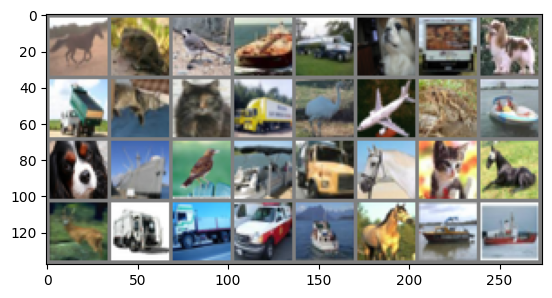

In [9]:
# Get random training images
images, _ = next(iter(trainloader))

# Show images (unnormalize and display)
plt.imshow(torchvision.utils.make_grid(images).permute(1, 2, 0) / 2 + 0.5)  # Unnormalize and permute
plt.show()

# 3. Model Definition

**This cell defines the CNN architecture with two convolution + pooling layers and two fully connected layers.  
The forward method describes how input flows through the network.**


In [10]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv Layer 1
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 32 x 16 x 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 64 x 8 x 8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Conv Layer 3
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # Output: 128 x 4 x 4

            nn.Flatten(),  # Flatten before FC
            nn.Linear(128 * 4 * 4, 512),  # FC Layer 1
            nn.ReLU(),
            nn.Linear(512, 10)  # Output Layer
        )

    def forward(self, x):
        return self.model(x)


# 4. Model Initialization, Loss Function, and Optimizer

**We set the device to GPU (if available) and move the model to it.  CrossEntropyLoss is used for classification, and Adam optimizer updates the weights.**


In [11]:
# Initialize model, loss function, optimizer, and device (CUDA if available)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)  # Move model to device (GPU or CPU)
criterion = nn.CrossEntropyLoss()  # Loss function used for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  # Optimizer for adjusting model parameters


# 5. Training Loop

**The model is trained for several epochs.  Each batch goes through forward pass, loss calculation, backward pass, and weight update.**


In [12]:
# Training Loop: Train the model for a specified number of epochs
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    train_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)  # Move to device (GPU/CPU)
        predictions = model(images) # Forward pass
        
        # Compute loss and backpropagate
        loss = criterion(predictions, labels)
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # Backpropagation
        optimizer.step()          # Update model parameters
        train_loss += loss.item()   # Track running loss

    # Print loss for the current epoch
    print(f'Epoch [{epoch+1}/{num_epochs}] | Loss: {train_loss / len(trainloader):.4f}')

Epoch [1/5] | Loss: 1.2857
Epoch [2/5] | Loss: 0.8468
Epoch [3/5] | Loss: 0.6638
Epoch [4/5] | Loss: 0.5196
Epoch [5/5] | Loss: 0.3932


# 6. Testing Loop

**The trained model is evaluated on the test set. We calculate total accuracy, along with correctly and incorrectly classified samples.**


In [21]:
# --- Testing Phase: Evaluate the trained model on the test set ---
correct, total = 0, 0   # Counters for correct and total predictions

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradients for inference
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Final stats
incorrect = total - correct
accuracy = 100 * correct / total  

print(f"Total validated points: {total}")
print(f"Correct classifications: {correct}")
print(f"Incorrect classifications: {incorrect}")
print(f"Test Accuracy: {accuracy:.2f}%")


Total validated points: 10000
Correct classifications: 7437
Incorrect classifications: 2563
Test Accuracy: 74.37%


# 7. Visualize Random Test Predictions


**This function visualizes a few random test images with their true and predicted labels. Correct predictions are shown in green, incorrect ones in red.**


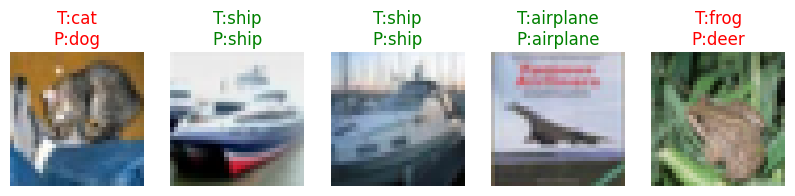

In [24]:
# Function to visualize random predictions from the test set
def visualize_predictions(model, testloader, num_images=5, device='cpu'):
    model.eval()
    images, labels = next(iter(testloader))  # take one batch
    images, labels = images.to(device), labels.to(device)

    preds = model(images).argmax(1)  # forward + predicted classes
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))

    for i, ax in enumerate(axes[:num_images]):
        img = images[i].cpu().permute(1, 2, 0).numpy() / 2 + 0.5  # unnormalize
        ax.imshow(img); ax.axis('off')

        true, pred = testset.classes[labels[i]], testset.classes[preds[i]]
        ax.set_title(f"T:{true}\nP:{pred}", color=('green' if true == pred else 'red'))

    plt.show()
visualize_predictions(model, testloader, num_images=5, device=device) # Visualize predictions

# 8. Conclusion

In this notebook, we built and trained a CNN in PyTorch to classify images from the CIFAR-10 dataset into 10 categories. Leveraging CNNs' strength in extracting spatial features, our model achieved a test accuracy of **75.8%**, demonstrating solid performance for a relatively simple architecture on a complex dataset. Visualising predictions showed that the model correctly classified many test images, though some misclassifications remain, highlighting potential areas for improvement through model tuning or data augmentation